# 들리다 (Deullida) 
> 한국어를 영어로 "들리게" 해주는 번역 서비스. 문장을 입력하면 영어로 번역하고, 한국어로 말하면 영어 텍스트와 음성으로 돌려줍니다

>모델 배포 개론 08  


In [1]:
pip install transformers sentencepiece fastapi "uvicorn[standard]" streamlit requests

Note: you may need to restart the kernel to use updated packages.


- 오디오 추가로 추가설치

In [2]:
pip install python-multipart

Note: you may need to restart the kernel to use updated packages.


In [1]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

# 작업 디렉터리를 app/ 가 있는 위치로 맞춥니다 (notebooks/ 안에서 열어도 동작).
if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# 코드를 저장할 폴더를 미리 만들어 둡니다.
for _d in ('app', 'models', 'data', 'frontend'):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}  # port -> (server, thread)

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다."""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.main:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    """
    stop_server(port)
    if _port_open(host, port):
        print(f'⚠️ 포트 {port}를 다른 프로세스가 사용 중입니다 (다른 노트북의 서버일 가능성).')
        print('   그 노트북에서 stop_server(8000)을 실행하거나 커널을 종료한 뒤, 이 셀을 다시 실행하세요.')
        return None
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일을 다시 저장한 경우 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        # Windows는 SelectorEventLoop, 그 외는 기본 이벤트 루프를 사용합니다.
        if sys.platform == 'win32':
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    # 모델 로드 때문에 기동이 느릴 수 있다 — 최대 5분 대기 (첫 실행은 다운로드 포함)
    for i in range(600):
        if _port_open(host, port):
            print(f'서버 실행됨: http://{host}:{port}')
            return server
        if not thread.is_alive():
            print('서버 스레드가 종료됐습니다. 위 로그를 확인하세요.')
            return server
        if i > 0 and i % 20 == 0:
            print(f'  ... 모델 로드 중 ({i//2}초 경과)')
        time.sleep(0.5)
    print('5분 내에 서버가 시작되지 않았습니다. 위 로그를 확인하세요.')
    return server

print('서버 도우미 준비 완료 (serve_in_thread, stop_server)')

서버 도우미 준비 완료 (serve_in_thread, stop_server)


In [3]:
%%writefile requirements.txt
torch==2.6.0
torchvision==0.21.0
transformers
sentencepiece
sacremoses
fastapi
uvicorn[standard]
streamlit
requests

Writing requirements.txt



## 1. 프로젝트 요구사항

---

### 1.1 조건

Day 5(주택 가격 예측)와 Day 6~7(이미지 분류 / 챗봇)에서 만든 서비스와 **동일한 구조**를 기본 베이스로 합니다. 

```
필수 구현 항목:

1. FastAPI 백엔드
   - 추론 엔드포인트 (POST /predict)
   - Pydantic으로 입력 검증
   - 비동기 추론 (run_in_executor)

2. API Key 인증
   - Day 6의 auth.py 재사용

3. Streamlit 프론트엔드
   - 사용자 입력 → API 호출 → 결과 표시

4. 에러 처리
   - 잘못된 입력, 모델 에러 시 적절한 HTTP 상태 코드 반환
```



### 1.2 제한 사항

```
하지 않는 것:

- 모델 학습 (사전학습 모델을 가져다 씁니다)
- Docker 패키징 (MLOps 과정에서 다룹니다)
- 데이터베이스 연동
```



### 1.3 평가 기준

```
✅ 서버가 정상적으로 실행되는가?
✅ Swagger UI에서 추론이 동작하는가?
✅ API Key 없이 요청하면 401이 반환되는가?
✅ 잘못된 입력에 대해 적절한 에러 메시지가 나오는가?
✅ Streamlit UI에서 입력 → 결과 확인이 가능한가?
```

---

## 2. 모델 선택 가이드

---

### 2.1 Hugging Face에서 모델 찾기

[Hugging Face Models](https://huggingface.co/models)에서 사전학습 모델을 선택합니다.
모델 학습은 하지 않고, `from_pretrained()`으로 바로 사용할 수 있는 모델을 고릅니다.

**모델 선택 시 확인할 것:**

```
1. 태스크가 명확한가? (text-classification, image-classification, summarization 등)
2. 한국어를 지원하는가? (필수는 아니지만, 데모가 직관적입니다)
3. 모델 크기가 적당한가? (CPU 환경이면 500MB 이하를 권장합니다)
4. pipeline()으로 바로 사용 가능한가?
```



### 2.2 도메인별 추천 예시

아래는 예시일 뿐입니다. **본인이 관심 있는 도메인을 자유롭게 선택하세요.**

| 도메인 | 태스크 | 추천 모델 (예시) |
|---|---|---|
| 감정 분석 | `text-classification` | `snunlp/KR-FinBert-SC` |
| 뉴스 분류 | `text-classification` | 원하는 분류 모델 |
| 텍스트 요약 | `summarization` | `eenzeenee/t5-base-korean` |
| 번역 | `translation` | `Helsinki-NLP` 시리즈 |
| 이미지 분류 | `image-classification` | `google/vit-base-patch16` |
| 객체 탐지 | `object-detection` | `facebook/detr-resnet-50` |
| 질의 응답 | `question-answering` | 원하는 QA 모델 |



### 2.3 모델 동작 확인

모델을 선택했으면, **서버 코드를 작성하기 전에** 노트북에서 먼저 동작을 확인합니다.

In [ ]:
# # 한 → 영 번역 모델 동작 확인
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# MODEL_NAME = "Helsinki-NLP/opus-mt-ko-en"
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# inputs = tokenizer("안녕하세요. 만나서 반갑습니다.", return_tensors="pt", truncation=True, max_length=512)
# outputs = model.generate(**inputs, max_length=512)
# print(tokenizer.decode(outputs[0], skip_special_tokens=True))
# # Hello, nice to meet you.

Loading weights: 100%|██████████| 258/258 [00:00<00:00, 10208.49it/s]


Hello. Nice to meet you.


In [4]:
# 오디오 모델 동작 확인 (STT + TTS)
from transformers import pipeline
import soundfile as sf, numpy as np, os
os.makedirs("data", exist_ok=True)

tts = pipeline("text-to-speech", model="facebook/mms-tts-eng")
out = tts("Hello, nice to meet you.")
sf.write("data/_tts_test.wav", np.asarray(out["audio"]).squeeze(), out["sampling_rate"])
print("TTS OK → data/_tts_test.wav", out["sampling_rate"])

stt = pipeline("automatic-speech-recognition", model="openai/whisper-small")
print("STT 모델 로드 OK (한국어는 Streamlit 마이크로 테스트)")

/home/irish/workplace/listen/.venv_listen/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 762/762 [00:00<00:00, 2334.47it/s]


TTS OK → data/_tts_test.wav 16000


Loading weights: 100%|██████████| 479/479 [00:00<00:00, 1884.96it/s]


STT 모델 로드 OK (한국어는 Streamlit 마이크로 테스트)


예시 코드입니다. 샘플 이미지 파일이 있어야 실행됩니다.

```python
# 예시: 이미지 분류
from transformers import pipeline

classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

result = classifier("test_image.jpg")
print(result)
# [{'label': 'tabby cat', 'score': 0.82}, ...]
```

> **이 셀이 정상 동작하면**, 서버 코드 작성으로 넘어갑니다.
> 여기서 에러가 나면, 모델을 바꾸거나 입력 형식을 확인하세요.



---

## 3. 프로젝트 뼈대 코드

---



### 3.1 폴더 구조

In [7]:
import os

dirs = ["app", "models", "frontend"]
for d in dirs:
    os.makedirs(d, exist_ok=True)

print("프로젝트 구조:")
print("""
listen/
├── 📁 app/
│   ├── auth.py              ← Day 6에서 만든 것 그대로 재사용
│   ├── schemas.py           ← 입력/출력 스키마 정의 (직접 작성)
│   ├── model_service.py     ← 모델 로드 + 추론 함수 (직접 작성)
│   └── main.py              ← FastAPI 서버 (직접 작성)
│
├── 📁 frontend/
│   └── app.py               ← Streamlit UI (직접 작성)
│
└── requirements.txt
""")

프로젝트 구조:

listen/
├── 📁 app/
│   ├── auth.py              ← Day 6에서 만든 것 그대로 재사용
│   ├── schemas.py           ← 입력/출력 스키마 정의 (직접 작성)
│   ├── model_service.py     ← 모델 로드 + 추론 함수 (직접 작성)
│   └── main.py              ← FastAPI 서버 (직접 작성)
│
├── 📁 frontend/
│   └── app.py               ← Streamlit UI (직접 작성)
│
└── requirements.txt



### 3.2 auth.py — 재사용

In [6]:
%%writefile app/auth.py
"""
Day 6에서 만든 인증 모듈을 그대로 재사용합니다.
"""
from fastapi import HTTPException, Header

VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )
    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )
    return VALID_API_KEYS[x_api_key]

Writing app/auth.py


### 3.3 schemas.py — 직접 작성

In [8]:
%%writefile app/schemas.py
"""한 → 영 번역 입력/출력 스키마"""
from pydantic import BaseModel, Field


class PredictRequest(BaseModel):
    text: str = Field(..., min_length=1, max_length=5000, description="번역할 한국어 문장")


class PredictResponse(BaseModel):
    success: bool
    source_text: str
    translated_text: str
    
# 오디오 출력 스키마 추가    
class VoiceTranslateResponse(BaseModel):
    success: bool
    korean_text: str        # 인식된 한국어
    english_text: str       # 영어 번역
    sampling_rate: int      # 음성 샘플레이트
    audio_base64: str       # 영어 음성(wav) base64    

Overwriting app/schemas.py


### 3.4 model_service.py — 직접 작성

In [ ]:
# %%writefile app/model_service.py
# """모델 로드 + 추론 (Helsinki-NLP/opus-mt-ko-en)"""
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# MODEL_NAME = "Helsinki-NLP/opus-mt-ko-en"


# def load_model():
#     tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
#     model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
#     return {"tokenizer": tokenizer, "model": model}


# def predict(model, text: str) -> dict:
#     tokenizer = model["tokenizer"]
#     net = model["model"]
#     inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
#     outputs = net.generate(**inputs, max_length=512)
#     return {"translated_text": tokenizer.decode(outputs[0], skip_special_tokens=True)}

Overwriting app/model_service.py


- model_service.py (교체 — STT/번역/TTS 통합)

In [5]:
%%writefile app/model_service.py
"""모델 로드 + 추론: 음성→번역→음성 (STT + 번역 + TTS)"""
import io
import numpy as np
import librosa
import soundfile as sf
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

TRANS_MODEL = "Helsinki-NLP/opus-mt-ko-en"
STT_MODEL = "openai/whisper-small"
TTS_MODEL = "facebook/mms-tts-eng"


def load_model():
    tokenizer = AutoTokenizer.from_pretrained(TRANS_MODEL)
    translator = AutoModelForSeq2SeqLM.from_pretrained(TRANS_MODEL)
    stt = pipeline("automatic-speech-recognition", model=STT_MODEL)
    tts = pipeline("text-to-speech", model=TTS_MODEL)
    return {"tokenizer": tokenizer, "translator": translator, "stt": stt, "tts": tts}


def translate(model, text: str) -> str:
    tokenizer, net = model["tokenizer"], model["translator"]
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    outputs = net.generate(**inputs, max_length=512)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


def transcribe(model, audio_bytes: bytes) -> str:
    # 업로드 오디오(wav) → 16kHz 모노 numpy (ffmpeg 없이 librosa로 디코드)
    wav, _ = librosa.load(io.BytesIO(audio_bytes), sr=16000, mono=True)
    result = model["stt"](
        {"array": wav, "sampling_rate": 16000},
        generate_kwargs={"language": "korean", "task": "transcribe"},
    )
    return result["text"].strip()


def synthesize(model, text: str):
    out = model["tts"](text)
    audio = np.asarray(out["audio"]).squeeze()
    sr = out["sampling_rate"]
    buf = io.BytesIO()
    sf.write(buf, audio, sr, format="WAV")
    return buf.getvalue(), sr


# 기존 텍스트 번역 호환용
def predict(model, text: str) -> dict:
    return {"translated_text": translate(model, text)}

Overwriting app/model_service.py


### 3.5 main.py — 직접 작성

In [ ]:
# %%writefile app/main.py
# """FastAPI 번역 서버"""
# import asyncio
# from concurrent.futures import ThreadPoolExecutor

# from fastapi import FastAPI, Depends, HTTPException

# from app.auth import verify_api_key
# from app.schemas import PredictRequest, PredictResponse
# from app.model_service import load_model, predict

# app = FastAPI(title="한→영 번역 API")
# executor = ThreadPoolExecutor(max_workers=1)
# _state = {}


# @app.on_event("startup")
# def _startup():
#     _state["model"] = load_model()


# @app.get("/health")
# def health():
#     return {"status": "ok", "model_loaded": "model" in _state}


# @app.post("/predict", response_model=PredictResponse)
# async def do_predict(req: PredictRequest, user: str = Depends(verify_api_key)):
#     model = _state.get("model")
#     if model is None:
#         raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")
#     try:
#         loop = asyncio.get_event_loop()
#         out = await loop.run_in_executor(executor, predict, model, req.text)
#     except Exception as e:
#         raise HTTPException(status_code=500, detail=f"추론 중 오류: {e}")
#     return PredictResponse(
#         success=True,
#         source_text=req.text,
#         translated_text=out["translated_text"],
#     )

Overwriting app/main.py


- main.py (교체 — /voice_translate 추가)

### 입력 제한 사항 (검증 정책)

| 구분 | 항목 | 제한 | 위반 시 |
|---|---|---|---|
| **텍스트** (`POST /predict`) | 필수 여부 | `text` 필드 필수 | 422 |
| | 빈 문자열 | `min_length=1` (빈 값 불가) | 422 |
| | 최대 길이 | `max_length=5000`자 | 422 |
| | 타입 | 문자열만 허용 | 422 |
| **오디오** (`POST /voice_translate`) | 필수 여부 | 파일 필수 (`UploadFile`) | 422 |
| | 빈 파일 | 0바이트 불가 | 422 |
| | 최대 크기 | `MAX_AUDIO_MB = 10` (10MB 이하) | 413 |
| | 포맷 | WAV 권장 (디코딩 실패 시) | 422 |
| **공통** | 인증 | `X-API-Key` 헤더 필수 | 401 |
| | 모델 미로드 | 서버 기동 직후 등 | 503 |
| | 추론 오류 | 모델 처리 중 예외 | 500 |

- **텍스트**: Pydantic 스키마(`PredictRequest`)로 자동 검증
- **오디오**: 파일이라 Pydantic 대신 엔드포인트에서 직접 검증 (빈 파일·크기·디코딩)
- **오디오 입력 형식**: 16kHz 모노로 변환 후 STT 처리 (`librosa`로 디코딩, ffmpeg 불필요 — WAV 기준)

In [4]:
%%writefile app/main.py
"""FastAPI: 텍스트 번역 + 음성→번역→음성"""
import base64
import asyncio
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException, UploadFile, File

from app.auth import verify_api_key
from app.schemas import PredictRequest, PredictResponse, VoiceTranslateResponse
from app.model_service import load_model, predict, transcribe, translate, synthesize

app = FastAPI(title="한→영 번역 + 음성 API")
executor = ThreadPoolExecutor(max_workers=1)  # 동기 추론을 돌릴 스레드풀 (이벤트 루프 비블로킹)
_state = {} # 로드된 모델을 담아둘 곳


@app.on_event("startup")
def _startup():
    # 서버 시작 시 모델을 한 번만 로드 (번역+STT+TTS)
    _state["model"] = load_model()


def _get_model():
    # 모델이 아직 로드 전이면 503 반환
    model = _state.get("model")
    if model is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")
    return model


@app.get("/health")
def health():
    # 서버·모델 상태 확인용
    return {"status": "ok", "model_loaded": "model" in _state}


@app.post("/predict", response_model=PredictResponse)
async def do_predict(req: PredictRequest, user: str = Depends(verify_api_key)):
    # 텍스트 번역 (한→영). 입력은 Pydantic으로 검증, 인증은 Depends로 적용
    model = _get_model()
    try:
        loop = asyncio.get_event_loop()
        # 동기 추론을 스레드풀에서 실행 → 서버가 멈추지 않음
        out = await loop.run_in_executor(executor, predict, model, req.text)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 중 오류: {e}")
    return PredictResponse(success=True, source_text=req.text, translated_text=out["translated_text"])


def _voice_pipeline(model, audio_bytes):
     # 음성 처리 3단계: 인식(STT) → 번역 → 합성(TTS)
    korean = transcribe(model, audio_bytes)              # 한국어 음성 → 한국어 텍스트
    english = translate(model, korean)                   # 한국어 → 영어 텍스트
    audio_wav, sr = synthesize(model, english)           # 영어 텍스트 → 영어 음성(wav)
    return korean, english, audio_wav, sr


@app.post("/voice_translate", response_model=VoiceTranslateResponse)
async def voice_translate(file: UploadFile = File(...), user: str = Depends(verify_api_key)):
    # 음성 파일 업로드 → 음성→번역→음성 전 과정
    model = _get_model()
    audio_bytes = await file.read()
    if not audio_bytes:
        raise HTTPException(status_code=422, detail="오디오 파일이 비어 있습니다.")   # 빈 파일 검증
    if len(audio_bytes) > MAX_AUDIO_MB * 1024 * 1024:                               # 최대 10MB 크기 제한
        raise HTTPException(status_code=413, detail=f"오디오가 너무 큽니다. {MAX_AUDIO_MB}MB 이하만 가능합니다.")
    try:
        loop = asyncio.get_event_loop()
        # 무거운 3단계 파이프라인도 스레드풀에서 비동기 실행 (run_in_executor)
        korean, english, audio_wav, sr = await loop.run_in_executor(
            executor, _voice_pipeline, model, audio_bytes
        )
    except Exception as e:
        # 오디오를 못 읽는 경우(잘못된 포맷 등)도 여기로 들어옴
        raise HTTPException(status_code=422, detail=f"오디오를 처리할 수 없습니다: {e}")
    return {
        "success": True,
        "korean_text": korean,
        "english_text": english,
        "sampling_rate": sr,
        # 오디오(wav)는 JSON으로 못 보내므로 base64 문자열로 인코딩해 전달
        "audio_base64": base64.b64encode(audio_wav).decode("ascii"),
    }

Overwriting app/main.py


### 3.6 frontend/app.py — 직접 작성

In [ ]:
# %%writefile frontend/app.py
# """Streamlit 번역 UI"""
# import streamlit as st
# import requests

# API_URL = "http://localhost:8000"

# st.title("한 → 영 번역 서비스")
# st.caption("모델: Helsinki-NLP/opus-mt-ko-en")

# api_key = st.sidebar.text_input("API Key", value="test-key-001", type="password")

# text = st.text_area("번역할 한국어 문장", height=150, placeholder="예) 오늘 날씨가 정말 좋네요.")

# if st.button("번역하기"):
#     if not text.strip():
#         st.warning("문장을 입력하세요.")
#     else:
#         try:
#             res = requests.post(
#                 f"{API_URL}/predict",
#                 json={"text": text},
#                 headers={"X-API-Key": api_key},
#                 timeout=60,
#             )
#             if res.status_code == 200:
#                 st.success("번역 완료")
#                 st.text_area("영어 번역", value=res.json()["translated_text"], height=150)
#             elif res.status_code == 401:
#                 st.error("인증 실패: API Key를 확인하세요.")
#             else:
#                 st.error(f"오류 {res.status_code}: {res.json().get('detail')}")
#         except Exception as e:
#             st.error(f"요청 실패: {e}")

Overwriting frontend/app.py


- 이어서 편하게 쓰려면 ① 입력 자동 비우기 + ② 번역 기록 누적 을 넣은 버전으로

In [ ]:
# %%writefile frontend/app.py
# """Streamlit 번역 UI"""
# import streamlit as st
# import requests

# API_URL = "http://localhost:8000"

# st.title("한 → 영 번역 서비스")
# st.caption("모델: Helsinki-NLP/opus-mt-ko-en")

# api_key = st.sidebar.text_input("API Key", value="test-key-001", type="password")

# if "history" not in st.session_state:
#     st.session_state.history = []

# with st.form("translate_form", clear_on_submit=True):
#     text = st.text_area("번역할 한국어 문장", height=120, placeholder="예) 내일 여행갈래?")
#     submitted = st.form_submit_button("번역하기")

# if submitted:
#     if not text.strip():
#         st.warning("문장을 입력하세요.")
#     else:
#         try:
#             res = requests.post(
#                 f"{API_URL}/predict",
#                 json={"text": text.strip()},
#                 headers={"X-API-Key": api_key},
#                 timeout=60,
#             )
#             if res.status_code == 200:
#                 st.session_state.history.insert(0, (text.strip(), res.json()["translated_text"]))
#             elif res.status_code == 401:
#                 st.error("인증 실패: API Key를 확인하세요.")
#             else:
#                 st.error(f"오류 {res.status_code}: {res.json().get('detail')}")
#         except Exception as e:
#             st.error(f"요청 실패: {e}")

# # 번역 기록 (최신순) — 국기 | 문장 을 좌우로 분리
# if st.session_state.history:
#     st.subheader("번역 기록")
#     for ko, en in st.session_state.history:
#         with st.container(border=True):
#             c1, c2 = st.columns([1, 11])
#             c1.write("🇰🇷")
#             c2.write(ko)
#             c1, c2 = st.columns([1, 11])
#             c1.write("🇺🇸")
#             c2.write(en)
#     if st.sidebar.button("기록 지우기"):
#         st.session_state.history = []
#         st.rerun()

Overwriting frontend/app.py


-  frontend/app.py (교체 — 텍스트 탭 + 음성 탭)

In [5]:
%%writefile frontend/app.py
"""Streamlit: 텍스트 번역 + 음성 번역(자동)"""
import base64
import hashlib
import streamlit as st
import requests

API_URL = "http://localhost:8000"

st.title("들리다 🎧")
st.caption("한 → 영 번역 서비스 · 텍스트 + 음성(음성→번역→음성)")

api_key = st.sidebar.text_input("API Key", value="test-key-001", type="password")

tab_text, tab_voice = st.tabs(["📝 텍스트 번역", "🎤 음성 번역"])

with tab_text:
    if "history" not in st.session_state:
        st.session_state.history = []
    with st.form("translate_form", clear_on_submit=True):
        text = st.text_area("번역할 한국어 문장", height=120, placeholder="예) 내일 여행갈래?")
        submitted = st.form_submit_button("번역하기")
    if submitted:
        if not text.strip():
            st.warning("문장을 입력하세요.")
        else:
            try:
                res = requests.post(f"{API_URL}/predict", json={"text": text.strip()},
                                    headers={"X-API-Key": api_key}, timeout=60)
                if res.status_code == 200:
                    st.session_state.history.insert(0, (text.strip(), res.json()["translated_text"]))
                elif res.status_code == 401:
                    st.error("인증 실패: API Key를 확인하세요.")
                else:
                    st.error(f"오류 {res.status_code}: {res.json().get('detail')}")
            except Exception as e:
                st.error(f"요청 실패: {e}")
    if st.session_state.history:
        st.subheader("번역 기록")
        for ko, en in st.session_state.history:
            with st.container(border=True):
                c1, c2 = st.columns([2, 11]); c1.markdown(":blue[🇰🇷 **한국어**]"); c2.write(ko)
                c1, c2 = st.columns([2, 11]); c1.markdown(":red[🇺🇸 **English**]"); c2.write(en)

with tab_voice:
    st.write("한국어로 녹음하거나 WAV 파일을 올리면 **자동으로** 인식·번역됩니다.")
    audio = st.audio_input("🎤 한국어로 말하기")
    uploaded = st.file_uploader("또는 WAV 파일 업로드", type=["wav"])
    src = audio or uploaded

    # 새 오디오가 들어오면 자동 처리 (같은 녹음 중복 처리 방지)
    if src is not None:
        audio_bytes = src.getvalue()
        digest = hashlib.md5(audio_bytes).hexdigest()
        if st.session_state.get("last_audio") != digest:
            st.session_state["last_audio"] = digest
            with st.spinner("인식 + 번역 중..."):
                try:
                    files = {"file": ("input.wav", audio_bytes, "audio/wav")}
                    res = requests.post(f"{API_URL}/voice_translate", files=files,
                                        headers={"X-API-Key": api_key}, timeout=120)
                    if res.status_code == 200:
                        st.session_state["voice_result"] = res.json()
                    elif res.status_code == 401:
                        st.session_state["voice_result"] = {"error": "인증 실패: API Key를 확인하세요."}
                    else:
                        st.session_state["voice_result"] = {"error": f"오류 {res.status_code}: {res.json().get('detail')}"}
                except Exception as e:
                    st.session_state["voice_result"] = {"error": f"요청 실패: {e}"}

    result = st.session_state.get("voice_result")
    if result:
        if "error" in result:
            st.error(result["error"])
        else:
            st.markdown(":blue[🇰🇷 **인식된 한국어**]"); st.write(result["korean_text"])
            st.markdown(":red[🇺🇸 **영어 번역**]"); st.write(result["english_text"])
            st.audio(base64.b64decode(result["audio_base64"]), format="audio/wav")

Overwriting frontend/app.py


- **텍스트 테스트 화면**
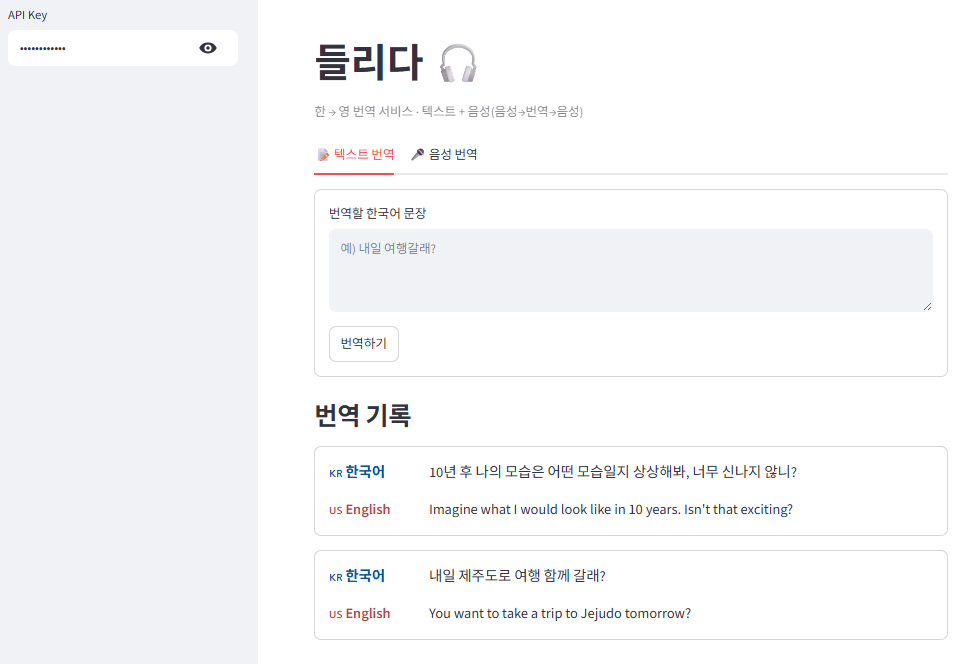


- **오디오 테스트 화면**
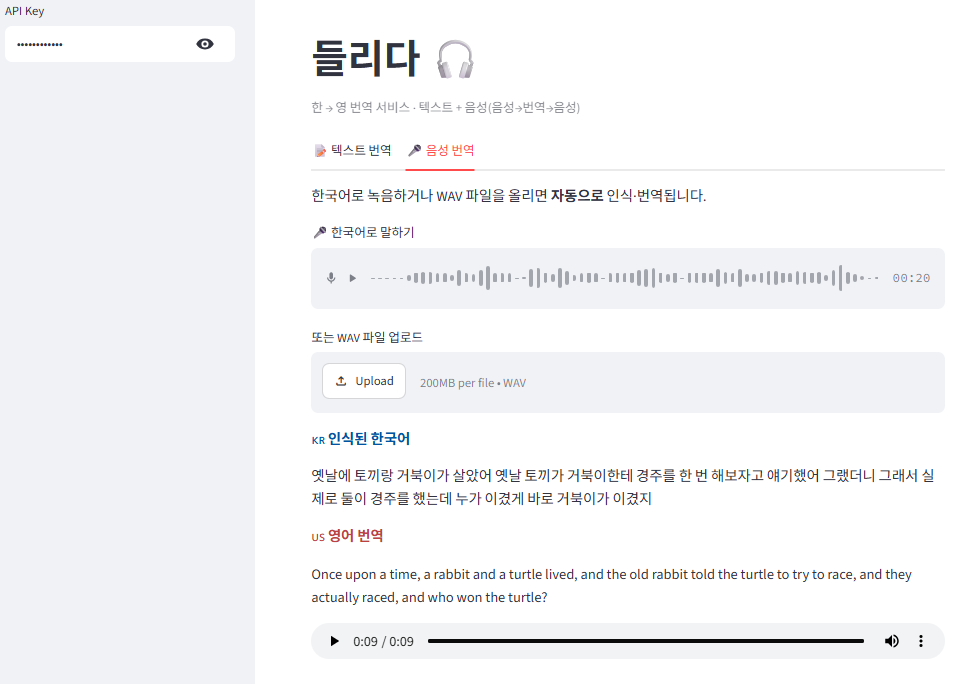

---

## 4. 작업 시간

---

### 4.1 권장 순서



```
Step 1. 모델 선택 + 노트북에서 동작 확인 (섹션 2.3)
        → "이 모델이 내 입력에 대해 결과를 반환하는가?"

Step 2. schemas.py 작성
        → "입력과 출력의 형태를 정의"

Step 3. model_service.py 작성
        → "모델 로드 + 추론 함수"

Step 4. main.py 작성
        → "FastAPI 서버 조립"

Step 5. 서버 실행 + Swagger UI 테스트
        → "API가 동작하는가?"

Step 6. frontend/app.py 작성
        → "Streamlit UI 연결"
```



### 4.2 서버 실행 (Step 5에서 사용)

> ⚠️ **코드를 수정했는데 반영이 안 될 때 — 커널을 재시작하세요.**
>
> `app/main.py`, `app/model_service.py` 등을 고친 뒤 아래 셀을 다시 실행해도,
> 이미 메모리에 올라간 이전 코드가 남아 변경이 반영되지 않을 수 있습니다.
> 코드를 수정했다면 **커널 재시작(Kernel → Restart) 후 맨 위 셀부터 다시 실행**하세요.

In [2]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.main:app", port=8000)

/home/irish/workplace/listen/.venv_listen/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ... 모델 로드 중 (10초 경과)


Loading weights: 100%|██████████| 479/479 [00:00<00:00, 1046.28it/s]


  ... 모델 로드 중 (20초 경과)


Loading weights: 100%|██████████| 762/762 [00:00<00:00, 1540.44it/s]


서버 실행됨: http://127.0.0.1:8000


- **Swagger UI Test**
    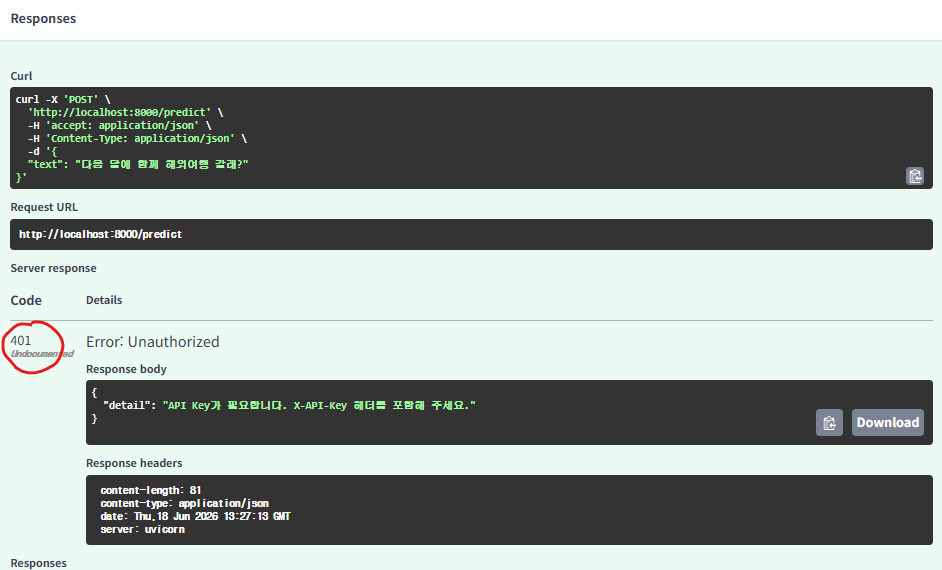
    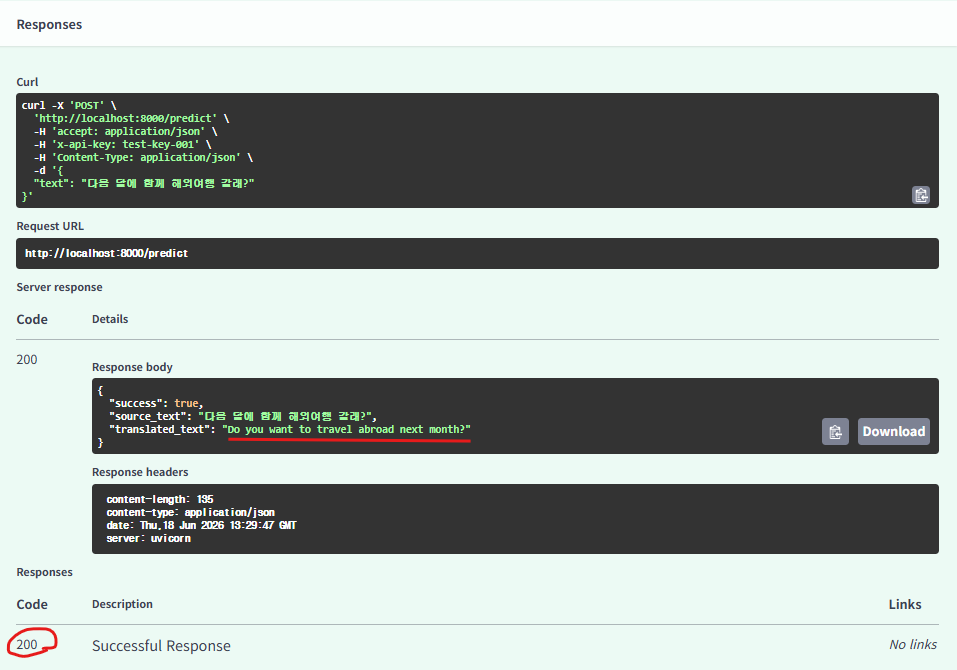
    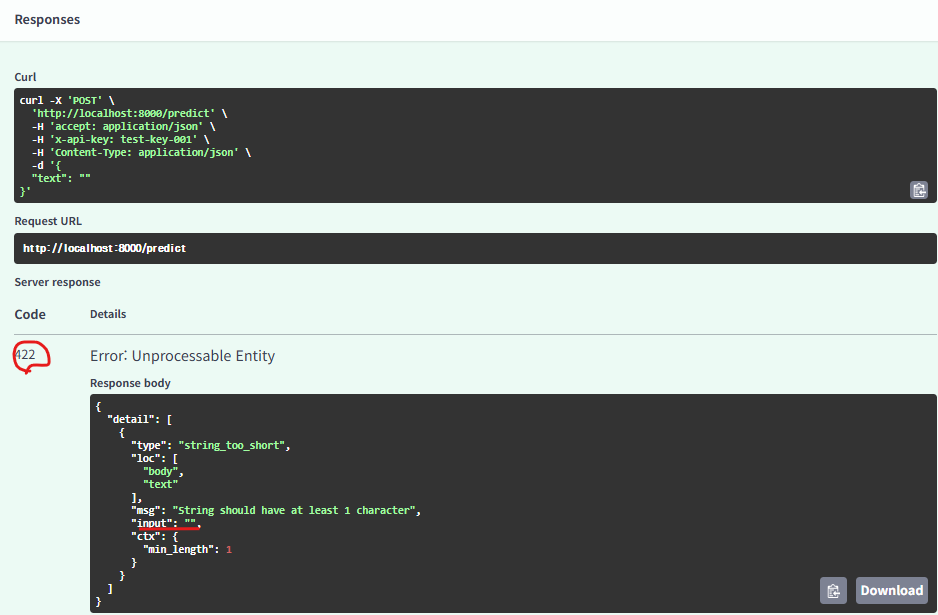

### 4.3 API 테스트 템플릿 (Step 5에서 사용)

In [4]:
import requests

API_URL = "http://localhost:8000"
HEADERS = {"X-API-Key": "test-key-001"}

print(requests.get(f"{API_URL}/health").json())

response = requests.post(
    f"{API_URL}/predict",
    json={"text": "오늘 날씨가 정말 덥네요."},
    headers=HEADERS,
)
print(f"상태: {response.status_code}")
print(f"결과: {response.json()}")

{'status': 'ok', 'model_loaded': True}
상태: 200
결과: {'success': True, 'source_text': '오늘 날씨가 정말 덥네요.', 'translated_text': "It's really hot today."}


### 4.4 막혔을 때 참고할 Day



```
"스키마를 어떻게 정의하지?"        → Day 2 섹션 4, Day 5 섹션 3
"FastAPI 서버 구조가 기억 안 나"   → Day 5 섹션 3, Day 6 섹션 6
"run_in_executor 사용법?"         → Day 3 섹션 4
"인증 적용 방법?"                  → Day 6 섹션 2
"Streamlit에서 API 호출?"         → Day 4 섹션 6, Day 5 섹션 4
"에러 처리?"                      → Day 3 섹션 5
```

---

## 5. 발표 및 회고

---



### 5.1 발표 내용

 항목:
1. 어떤 도메인/태스크를 선택했는가?
  - 번역(Translation) 도메인입니다. 단순 텍스트 번역에서 한 걸음 더 나아가, 음성 기반 한→영 번역까지 구현했습니다.
    - 텍스트: 한국어 문장 > 영어 번역
    - 음  성: 한국어 음성 > (인식) 한국어 텍스트 > (번역) 영어 > (합성) 영어 음성
  - 프로젝트 이름은 "들리다" — 한국어가 영어로 "들리게" 한다는 의미로, 음성 입출력이라는 핵심을 담았습니다.

2. 어떤 모델을 사용했는가? (선택 이유)
  - 세개의 사전학습 모델을 조합함.
    - 번역 (한→영)	 : Helsinki-NLP/opus-mt-ko-en :	가볍고(약 300MB) CPU에서도 빠름, 가이드 추천
    - 음성 인식 (STT): openai/whisper-small       : 한국어 인식 품질·크기 균형이 좋음
    - 음성 합성 (TTS): facebook/mms-tts-eng	      : speaker 설정 불필요, 영어 음성 합성이 간단

3. 데모 시연 (Swagger UI 또는 Streamlit)
  - Swagger UI (localhost:8000/docs)
  - Streamlit (localhost:8501)

4. 구현하면서 가장 어려웠던 부분은?
  - 가상환경을 새롭게 구축하려다가 디스크 full 발생으로 파일 정리하다가 시간을 많이 소모했습니다.
  - 항상 프로젝트 할 때 사용 모델의 환경 잡는게 가장 어렵고 시간이 걸립니다.
  - 오디오를 음성 단계에선 STT·번역·TTS 세 모델을 하나의 서버에서 조립하고, 오디오를 ffmpeg 없이 librosa로 디코드해 넘기는 부분을 맞추는 게 까다로웠습니다. librosa를 사용하므로 mp3는 지원하지 않는 한계가 있습니다.

### 5.2 회고

새로운 가상환경을 구축하고, 필요한 lib를 설치하는 과정에서 난데없는 disk full 발생으로 시간을 소모했지만, 며칠전 코엑스에서 봤던 실시간 번역기를 만들어 보고 싶어서 시작했다.  결론적으로 실시간 번역까지는 못해도, 허깅페이스에서 제공하는 모델들을 조합해서 한국어->영어 텍스트/음성 번역기를 만들어 보았다.<br>
 서버 골격(FastAPI + Pydantic + 인증 + 비동기 추론)은 Day 5~7에서 반복한 패턴이어서 수월했으나, 음성(STT·TTS)을 붙이면서 모델을 여러 개 조합하는 부분은 AI의 도움으로 진행했다.<br><br>

run_in_executor(Day 3), Depends 인증 적용(Day 6), Streamlit의 API 호출(Day 4~5)을 다시 봤고, 교안보다도 환경 문제(disk full로 WSL 다운, transformers 버전 호환, 커널 캐시) 해결에 시간을 더 썼다. <br><br>

다음에 다시 만든다면, 모델 받기 전에 디스크·가상환경 점검을 통해서 꼭 필요한 것만 설치하도록 하고, 소스 수정 후 커널 재시작 습관화 하겠다.
<br><br>

코엑스에서 본 다양한 실시간 번역기들이 별거 아닌것처럼 보였어도 실제로 만들어보니 간단한 것이 아니라는 것을 느꼈다. 시간이 된다면 지금 만든 "들리다"를 좀더 발전시켜보고 싶다.


---


### ✅ Day 8 최종 체크포인트

Q1. 본인의 프로젝트에서 Pydantic 검증은 어떤 잘못된 입력을 막아줍니까?
- schemas.py의 PredictRequest에서 text: str = Field(..., min_length=1, max_length=5000)로 정의했습니다. 
- 이 검증이 막아주는 입력은:
    - text 필드가 아예 없는 요청 (필수 필드 누락 → 422)
    - 빈 문자열 "" (min_length=1 위반 → 422) — 실제로 테스트해서 422 확인
    - 5000자 초과 입력 (max_length 위반)
    - text가 문자열이 아닌 타입(숫자·리스트 등 → 타입 검증 실패 422)
    - 즉 모델에 도달하기 전에 비정상 입력을 걸러, 추론 단계에서 터질 에러를 미리 방지합니다.

Q2. Depends(verify_api_key)를 제거하면 어떤 위험이 있습니까?
- 인증이 사라져 누구나 /predict를 호출할 수 있습니다. 결과적으로,
    - 호출자를 식별·제한할 수 없어 무단 사용 / 대량 요청(DoS) 에 노출
    - 번역 추론은 CPU·메모리를 쓰는 작업이라 리소스 고갈로 정상 사용자까지 느려짐
    - 외부에 공개 시 비용·자원 남용 통제 불가
    - 실제로 키 없이 호출하면 401이 반환되는 것을 확인했고, 이게 그 보호 장치입니다.

Q3. run_in_executor를 사용한 이유는 무엇입니까?
- 번역·STT·TTS 추론은 모두 동기·CPU 바운드 작업이라, 그냥 호출하면 FastAPI의 이벤트 루프를 블로킹합니다. 그러면 추론이 끝날 때까지 /health 같은 다른 요청도 멈춥니다. 
- run_in_executor로 추론을 별도 스레드풀에서 실행해, 추론 중에도 서버가 다른 요청을 받을 수 있도록 동시성(비블로킹) 을 유지하기 위해서입니다.

Q4. Day 1~8 중 가장 많이 참고한 Day는 어디였습니까? 왜?
- Day 5와 Day 6입니다. Day 5의 FastAPI 서버 구조(startup 모델 로드, /predict 엔드포인트, Pydantic 스키마)를 뼈대로 삼았고, Day 6의 auth.py를 그대로 재사용해 API Key 인증을 붙였습니다. 번역이라는 태스크만 다를 뿐, 서빙 구조 자체는 이 두 Day의 패턴을 거의 그대로 따랐습니다.

Q5. 이 서비스를 실제로 배포하려면 추가로 무엇이 필요합니까?
- Docker 패키징 + 클라우드 배포(AWS/GCP 등)
- HTTPS / 도메인, API Key를 코드 하드코딩이 아닌 환경변수·시크릿으로 관리
- 로깅·모니터링(Prometheus/Grafana), 에러 추적
- Rate limiting, 동시 요청 대비 워커/리소스 설정(필요 시 GPU)
- 코드 변경 자동 반영을 위한 CI/CD 파이프라인

---

### 📌 Day 8 요약 & 전체 과정 완료

```
오늘 한 일:
  ✅ Day 1~7의 기술을 조합하여 나만의 서비스를 직접 만들었습니다.
  ✅ 교안 없이 설계 → 구현 → 테스트를 경험했습니다.
  ✅ 8일간의 여정을 회고하고, MLOps로 가는 길을 확인했습니다.

8일간의 전체 성과:
  🎉 PyTorch / HuggingFace 모델을 API로 서빙할 수 있습니다.
  🎉 비개발자도 사용 가능한 웹 UI를 붙일 수 있습니다.
  🎉 인증, 에러 처리, 로깅으로 안정적인 서비스를 만들 수 있습니다.
  🎉 스스로 설계하고 구현할 수 있다는 자신감을 얻었습니다.
```

### 제출
[제출 링크](https://forms.gle/AuzFv19QmyWh6rgc6)

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 프로젝트 실행 내역 캡쳐와 설명
2. 각 섹션 체크포인트의 답변
3. 프로젝트 회고

수고하셨습니다!